In [5]:
!apt-get install -y graphviz
!pip install deap networkx pydot matplotlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
Iniciando diseño automatizado del circuito...

gen	nevals	Mejor	Promedio
0  	400   	8    	4.935   
1  	307   	9    	6.2325  
2  	304   	9    	7.04    
3  	308   	9    	7.4     
4  	277   	9    	7.69    
5  	306   	9    	7.725   
6  	301   	9    	7.9025  
7  	315   	9    	8.035   
8  	296   	9    	8.1975  
9  	294   	9    	8.2625  
10 	309   	9    	8.25    
11 	306   	10   	8.305   
12 	284   	10   	8.4475  
13 	294   	10   	8.495   
14 	326   	10   	8.405   
15 	300   	10   	8.585   
16 	316   	10   	8.7875  
17 	309   	10   	9.1075  
18 	295   	10   	9.4175  
19 	320   	10   	9.4575  
20 	303   	10   	9.48    
21 	297   	10   	9.5275  
22 	296   	10   	9.4675  
23 	301   	10   	9.6175  
24 	306   	10   	9.5975  
25 	316   	10   	9.5125  
26 	306   	10   	9.6225  
27 	3

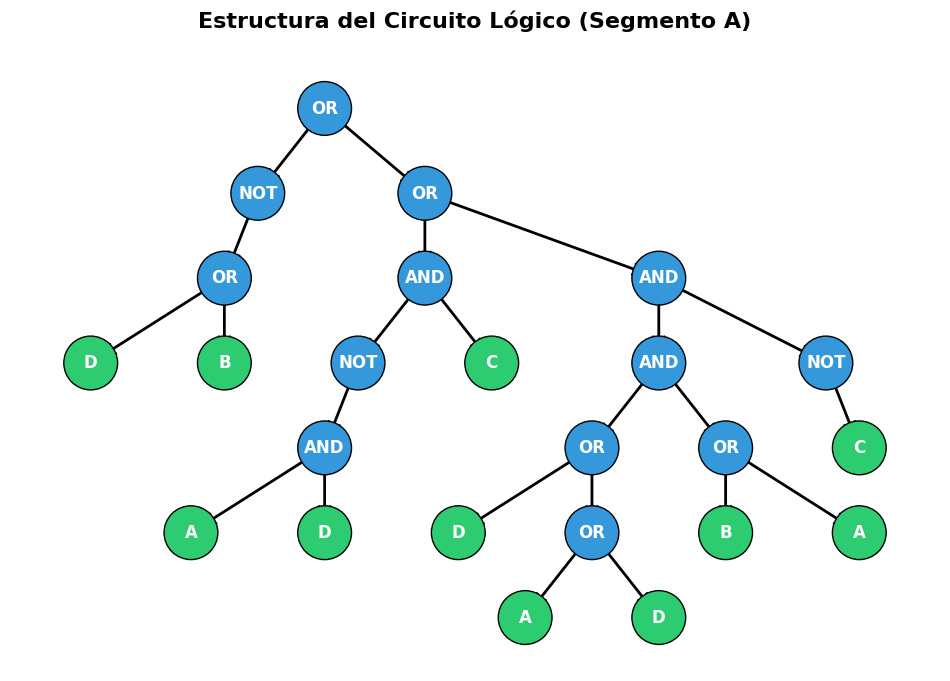

In [4]:
import random
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from networkx.drawing.nx_pydot import graphviz_layout
from deap import base, creator, tools, gp, algorithms

# ==========================================
# 2. CONJUNTO DE FUNCIONES (Compuertas Lógicas)
# ==========================================
def compuerta_and(x, y): return int(x and y)
def compuerta_or(x, y):  return int(x or y)
def compuerta_not(x):    return int(not x)

# Definimos el conjunto primitivo con 4 terminales (Bits A, B, C, D)
pset = gp.PrimitiveSet("MAIN", 4)
pset.addPrimitive(compuerta_and, 2, name="AND")
pset.addPrimitive(compuerta_or, 2, name="OR")
pset.addPrimitive(compuerta_not, 1, name="NOT")
pset.renameArguments(ARG0='A', ARG1='B', ARG2='C', ARG3='D')

# ==========================================
# 3. CONFIGURACIÓN DEL ENTORNO EVOLUTIVO
# ==========================================
# Limpiamos clases previas por si se ejecuta varias veces en Colab
if "FitnessMax" in dir(creator): del creator.FitnessMax
if "Individual" in dir(creator): del creator.Individual

creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", gp.PrimitiveTree, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("expr", gp.genHalfAndHalf, pset=pset, min_=1, max_=3)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.expr)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("compile", gp.compile, pset=pset)

# ==========================================
# 4. FUNCIÓN DE APTITUD (Tabla de Verdad)
# ==========================================
# Tabla de verdad del Segmento 'A' (1 = Encendido, 0 = Apagado)
tabla_verdad_seg_A = {
    (0,0,0,0): 1, (0,0,0,1): 0, (0,0,1,0): 1, (0,0,1,1): 1,
    (0,1,0,0): 0, (0,1,0,1): 1, (0,1,1,0): 1, (0,1,1,1): 1,
    (1,0,0,0): 1, (1,0,0,1): 1
}

def evaluar_circuito(individual):
    funcion_circuito = toolbox.compile(expr=individual)
    aciertos = 0
    for entradas, salida_esperada in tabla_verdad_seg_A.items():
        if funcion_circuito(*entradas) == salida_esperada:
            aciertos += 1
    return aciertos,

toolbox.register("evaluate", evaluar_circuito)
toolbox.register("select", tools.selTournament, tournsize=5) # Aumentamos presión selectiva
toolbox.register("mate", gp.cxOnePoint)
toolbox.register("expr_mut", gp.genFull, min_=0, max_=2)
toolbox.register("mutate", gp.mutUniform, expr=toolbox.expr_mut, pset=pset)

# ==========================================
# 5. MÓDULO DE VISUALIZACIÓN GRÁFICA
# ==========================================
def dibujar_arbol_logico(individuo):
    """Convierte el ADN del circuito en un grafo visual y lo dibuja."""
    nodos, aristas, etiquetas = gp.graph(individuo)

    grafo = nx.DiGraph()
    grafo.add_nodes_from(nodos)
    grafo.add_edges_from(aristas)

    # Usamos graphviz para darle estructura de árbol jerárquico descendente
    posiciones = graphviz_layout(grafo, prog="dot")

    # Configuración de colores (Terminales vs Compuertas)
    colores_nodos = ['#2ecc71' if etiquetas[n] in ['A', 'B', 'C', 'D'] else '#3498db' for n in nodos]

    plt.figure(figsize=(12, 8))
    nx.draw_networkx_nodes(grafo, posiciones, node_size=1500, node_color=colores_nodos, edgecolors='black')
    nx.draw_networkx_edges(grafo, posiciones, arrowstyle='->', arrowsize=20, width=2)
    nx.draw_networkx_labels(grafo, posiciones, etiquetas, font_size=12, font_color='white', font_weight='bold')

    plt.title("Estructura del Circuito Lógico (Segmento A)", fontsize=16, fontweight='bold', pad=20)
    plt.axis('off')
    plt.show()

# ==========================================
# 6. CICLO DE EVOLUCIÓN Y RESULTADOS
# ==========================================
def diseñar_circuito():
    random.seed(42)
    pop = toolbox.population(n=400) # Población ligeramente mayor
    hof = tools.HallOfFame(1)

    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("Mejor", np.max)
    stats.register("Promedio", np.mean)

    print("Iniciando diseño automatizado del circuito...\n")
    algorithms.eaSimple(pop, toolbox, cxpb=0.7, mutpb=0.2, ngen=50,
                        stats=stats, halloffame=hof, verbose=True)

    return hof[0]

# Ejecución
mejor_circuito = diseñar_circuito()

print("\n" + "="*50)
print("🎯 DISEÑO ÓPTIMO ENCONTRADO")
print("="*50)
print(f"Puntuación de Aptitud : {mejor_circuito.fitness.values[0]} / 10 aciertos")
print(f"Ecuación Lógica       : {mejor_circuito}")
print("="*50 + "\n")

# Llamamos a la función para dibujar el circuito
dibujar_arbol_logico(mejor_circuito)